# Analyse exploratoire - Attrition employé

Objectifs :
- explorer les 3 fichiers sources
- vérifier et préparer les clés de jointure
- construire un DataFrame central
- comparer les employés ayant quitté l'entreprise à ceux qui sont restés

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Chargement des données

In [2]:
sirh = pd.read_csv("../data/extrait_sirh.csv", sep=",")
eval_df = pd.read_csv("../data/extrait_eval.csv", sep=",")
sondage = pd.read_csv("../data/extrait_sondage.csv", sep=",")

## Inspection initiale des fichiers

In [3]:
for name, df in {
    "sirh": sirh,
    "eval": eval_df,
    "sondage": sondage
}.items():
    print(f"\n===== {name.upper()} =====")
    display(df.head())
    print("Shape :", df.shape)
    print("\nInfos :")
    df.info()
    print("\nValeurs manquantes :")
    display(df.isna().sum())
    print("Doublons :", df.duplicated().sum())


===== SIRH =====


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


Shape : (1470, 12)

Infos :
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 137.9 KB

V

id_employee                       0
age                               0
genre                             0
revenu_mensuel                    0
statut_marital                    0
departement                       0
poste                             0
nombre_experiences_precedentes    0
nombre_heures_travailless         0
annee_experience_totale           0
annees_dans_l_entreprise          0
annees_dans_le_poste_actuel       0
dtype: int64

Doublons : 0

===== EVAL =====


...

Doublons : 0

===== SONDAGE =====


,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


Shape : (1470, 12)

Infos :
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        14

a_quitte_l_entreprise                  0
nombre_participation_pee               0
nb_formations_suivies                  0
nombre_employee_sous_responsabilite    0
code_sondage                           0
distance_domicile_travail              0
niveau_education                       0
domaine_etude                          0
ayant_enfants                          0
frequence_deplacement                  0
annees_depuis_la_derniere_promotion    0
annes_sous_responsable_actuel          0
dtype: int64

Doublons : 0


Les trois fichiers contiennent chacun 1470 lignes, sans valeurs manquantes ni doublons de ligne. Les données semblent cohérentes.

## Préparation des identifiants de jointure

In [4]:
eval_df["id_employee"] = eval_df["eval_number"].str.replace("E_", "", regex=False).astype(int)

In [5]:
print("sirh :", sirh["id_employee"].nunique(), "/", len(sirh))
print("sondage :", sondage["code_sondage"].nunique(), "/", len(sondage))
print("eval :", eval_df["id_employee"].nunique(), "/", len(eval_df))

print(set(sirh["id_employee"]) - set(sondage["code_sondage"]))
print(set(sondage["code_sondage"]) - set(sirh["id_employee"]))
print(set(sirh["id_employee"]) - set(eval_df["id_employee"]))

sirh : 1470 / 1470
sondage : 1470 / 1470
eval : 1470 / 1470
set()
set()
set()


Les identifiants correspondent parfaitement entre les trois fichiers. La jointure peut donc être réalisée au niveau employé.

## Nettoyage minimal de certaines variables

In [6]:
eval_df["augementation_salaire_precedente"] = eval_df["augementation_salaire_precedente"].str.replace("%", "", regex=False).str.strip().astype(float)

eval_df["heure_supplementaires"] = eval_df["heure_supplementaires"].map({"Oui": 1, "Non": 0})
sondage["a_quitte_l_entreprise"] = sondage["a_quitte_l_entreprise"].map({"Oui": 1, "Non": 0})
sondage["ayant_enfants"] = sondage["ayant_enfants"].map({"Y": 1, "N": 0})

In [7]:
sirh.dtypes
eval_df.dtypes
sondage.dtypes

a_quitte_l_entreprise                  int64
nombre_participation_pee               int64
nb_formations_suivies                  int64
nombre_employee_sous_responsabilite    int64
code_sondage                           int64
distance_domicile_travail              int64
niveau_education                       int64
domaine_etude                            str
ayant_enfants                          int64
frequence_deplacement                    str
annees_depuis_la_derniere_promotion    int64
annes_sous_responsable_actuel          int64
dtype: object

## Construction du DataFrame central

In [8]:
df_central = (
    sirh
    .merge(sondage, left_on="id_employee", right_on="code_sondage", how="inner")
    .merge(eval_df, on="id_employee", how="inner")
)

In [9]:
df_central = df_central.drop(columns=["code_sondage", "eval_number"])

In [41]:
df_central = df_central.rename(columns={
    "nombre_heures_travailless": "nombre_heures_travaillees",
    "annes_sous_responsable_actuel": "annees_sous_responsable_actuel"
})

In [42]:
print(df_central.shape)
display(df_central.head())
df_central.info()

(1470, 32)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travaillees,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,1,0,0,1,1,2,Infra & Cloud,1,Occasionnel,0,5,2,3,2,4,1,1,3,1,11.0
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,0,1,3,1,8,1,Infra & Cloud,1,Frequent,1,7,3,2,2,2,4,3,4,0,23.0
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,1,0,3,1,2,2,Autre,1,Occasionnel,0,0,4,2,1,3,2,3,3,1,15.0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,0,0,3,1,3,4,Infra & Cloud,1,Frequent,3,0,4,3,1,3,3,3,3,1,11.0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,0,1,3,1,2,1,Transformation Digitale,1,Occasionnel,2,2,1,3,1,2,4,3,3,0,12.0


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   str    
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   str    
 5   departement                                1470 non-null   str    
 6   poste                                      1470 non-null   str    
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travaillees                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise           

In [24]:
print("Doublons :", df_central.duplicated().sum())
print("Employés uniques :", df_central["id_employee"].nunique(), "/", len(df_central))

Doublons : 0
Employés uniques : 1470 / 1470


La jointure aboutit à un DataFrame central de 1470 lignes, avec un employé par ligne. Aucun doublon supplémentaire n’est généré.

## Statistiques descriptives

In [12]:
df_central["a_quitte_l_entreprise"].value_counts()

a_quitte_l_entreprise
0    1233
1     237
Name: count, dtype: int64

In [13]:
df_central["a_quitte_l_entreprise"].value_counts(normalize=True) * 100

a_quitte_l_entreprise
0    83.877551
1    16.122449
Name: proportion, dtype: float64

In [14]:
num_cols = df_central.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [col for col in num_cols if col != "a_quitte_l_entreprise"]

df_central.groupby("a_quitte_l_entreprise")[num_cols].mean().T

a_quitte_l_entreprise,0,1
id_employee,1027.656123,1010.345992
age,37.561233,33.607595
revenu_mensuel,6832.739659,4787.092827
nombre_experiences_precedentes,2.645580,2.940928
nombre_heures_travailless,80.000000,80.000000
annee_experience_totale,11.862936,8.244726
annees_dans_l_entreprise,7.369019,5.130802
annees_dans_le_poste_actuel,4.484185,2.902954
nombre_participation_pee,0.845093,0.527426
nb_formations_suivies,2.832928,2.624473


In [15]:
df_central.groupby("a_quitte_l_entreprise")[num_cols].median().T

a_quitte_l_entreprise,0,1
id_employee,1022.0,1017.0
age,36.0,32.0
revenu_mensuel,5204.0,3202.0
nombre_experiences_precedentes,2.0,1.0
nombre_heures_travailless,80.0,80.0
annee_experience_totale,10.0,7.0
annees_dans_l_entreprise,6.0,3.0
annees_dans_le_poste_actuel,3.0,2.0
nombre_participation_pee,1.0,0.0
nb_formations_suivies,3.0,2.0


In [16]:
for col in ["genre", "departement", "poste", "statut_marital", "domaine_etude", "frequence_deplacement"]:
    print(f"\n===== {col} =====")
    display(pd.crosstab(df_central[col], df_central["a_quitte_l_entreprise"], normalize="index") * 100)


===== genre =====


a_quitte_l_entreprise,0,1
genre,,
F,85.204082,14.795918
M,82.993197,17.006803



===== departement =====


a_quitte_l_entreprise,0,1
departement,,
Commercial,79.372197,20.627803
Consulting,86.160250,13.839750
Ressources Humaines,80.952381,19.047619



===== poste =====


...

a_quitte_l_entreprise,0,1
statut_marital,,
Célibataire,74.468085,25.531915
Divorcé(e),89.908257,10.091743
Marié(e),87.518574,12.481426



===== domaine_etude =====


a_quitte_l_entreprise,0,1
domaine_etude,,
Autre,86.585366,13.414634
Entrepreunariat,75.757576,24.242424
Infra & Cloud,85.313531,14.686469
Marketing,77.987421,22.012579
Ressources Humaines,74.074074,25.925926
Transformation Digitale,86.422414,13.577586



===== frequence_deplacement =====


a_quitte_l_entreprise,0,1
frequence_deplacement,,
Aucun,92.000000,8.000000
Frequent,75.090253,24.909747
Occasionnel,85.043145,14.956855


### Premiers constats

- Les employés ayant quitté l’entreprise sont en moyenne plus jeunes, moins expérimentés, moins anciens dans l’entreprise et dans leur poste actuel.
- Leur revenu mensuel est nettement plus faible, ce qui suggère un lien possible entre niveau de rémunération et attrition.
- Les heures supplémentaires ressortent comme un facteur potentiellement important : elles concernent beaucoup plus souvent les employés ayant quitté l’entreprise.
- Les niveaux de satisfaction sont systématiquement un peu plus faibles chez les employés partis, notamment sur l’environnement de travail, la nature du travail et l’équilibre pro/perso.
- Certaines catégories semblent plus exposées à l’attrition, notamment les Représentants Commerciaux, les Consultants, les célibataires et les salariés avec des déplacements fréquents.

## Tests statistiques

En complément de l’analyse descriptive, on réalise des tests statistiques afin de vérifier si les écarts observés entre les employés ayant quitté l’entreprise et ceux qui sont restés sont statistiquement significatifs (peu susceptibles d’être dus au hasard).

- Le test de Mann–Whitney U est utilisé pour comparer deux groupes indépendants sur une variable numérique. Il repose sur les rangs des observations.
- Le test de Kolmogorov–Smirnov est utilisé pour comparer la distribution globale d’une variable numérique entre deux groupes. Il permet d’évaluer si les deux groupes présentent une répartition similaire ou si leurs distributions diffèrent.

Pour ces deux tests, l’interprétation repose principalement sur la p-value : une p-value inférieure à 0,05 indique qu’il est peu probable d’observer un tel écart si les deux groupes étaient en réalité similaires.

In [32]:
num_test_cols = [
    "age",
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "distance_domicile_travail",
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso"
]

In [33]:
results_mwu = []

for col in num_test_cols:
    group_0 = df_central.loc[df_central["a_quitte_l_entreprise"] == 0, col]
    group_1 = df_central.loc[df_central["a_quitte_l_entreprise"] == 1, col]

    stat, p_value = stats.mannwhitneyu(group_0, group_1, alternative="two-sided")

    results_mwu.append({
        "variable": col,
        "statistique_mwu": stat,
        "p_value_mwu": p_value,
        "significatif_5pct": p_value < 0.05
    })

df_mwu = pd.DataFrame(results_mwu).sort_values("p_value_mwu")
df_mwu

,variable,statistique_mwu,p_value_mwu,significatif_5pct
2,annee_experience_totale,191654.0,2.399569e-14,True
1,revenu_mensuel,191600.5,2.950831e-14,True
3,annees_dans_l_entreprise,189639.0,2.916191e-13,True
4,annees_dans_le_poste_actuel,187007.0,4.429560e-12,True
0,age,185362.0,5.304342e-11,True
7,satisfaction_employee_nature_travail,168858.5,7.957918e-05,True
6,satisfaction_employee_environnement,167434.0,2.173049e-04,True
5,distance_domicile_travail,127995.5,2.387047e-03,True
9,satisfaction_employee_equilibre_pro_perso,156511.5,4.647300e-02,True
8,satisfaction_employee_equipe,155542.5,1.020252e-01,False


In [34]:
results_ks = []

for col in num_test_cols:
    group_0 = df_central.loc[df_central["a_quitte_l_entreprise"] == 0, col]
    group_1 = df_central.loc[df_central["a_quitte_l_entreprise"] == 1, col]

    stat, p_value = stats.ks_2samp(group_0, group_1)

    results_ks.append({
        "variable": col,
        "statistique_ks": stat,
        "p_value_ks": p_value,
        "significatif_5pct": p_value < 0.05
    })

df_ks = pd.DataFrame(results_ks).sort_values("p_value_ks")
df_ks

,variable,statistique_ks,p_value_ks,significatif_5pct
1,revenu_mensuel,0.261901,1.674600e-12,True
0,age,0.243761,7.134536e-11,True
3,annees_dans_l_entreprise,0.238895,1.859519e-10,True
2,annee_experience_totale,0.235630,3.496219e-10,True
4,annees_dans_le_poste_actuel,0.218804,7.829981e-09,True
6,satisfaction_employee_environnement,0.131859,1.772436e-03,True
5,distance_domicile_travail,0.114930,9.527283e-03,True
7,satisfaction_employee_nature_travail,0.110680,1.401505e-02,True
9,satisfaction_employee_equilibre_pro_perso,0.073650,2.185725e-01,False
8,satisfaction_employee_equipe,0.062891,3.927862e-01,False


In [35]:
df_tests = df_mwu.merge(df_ks, on="variable")[[
    "variable",
    "statistique_mwu",
    "p_value_mwu",
    "statistique_ks",
    "p_value_ks"
]].sort_values("p_value_mwu")

df_tests

,variable,statistique_mwu,p_value_mwu,statistique_ks,p_value_ks
0,annee_experience_totale,191654.0,2.399569e-14,0.235630,3.496219e-10
1,revenu_mensuel,191600.5,2.950831e-14,0.261901,1.674600e-12
2,annees_dans_l_entreprise,189639.0,2.916191e-13,0.238895,1.859519e-10
3,annees_dans_le_poste_actuel,187007.0,4.429560e-12,0.218804,7.829981e-09
4,age,185362.0,5.304342e-11,0.243761,7.134536e-11
5,satisfaction_employee_nature_travail,168858.5,7.957918e-05,0.110680,1.401505e-02
6,satisfaction_employee_environnement,167434.0,2.173049e-04,0.131859,1.772436e-03
7,distance_domicile_travail,127995.5,2.387047e-03,0.114930,9.527283e-03
8,satisfaction_employee_equilibre_pro_perso,156511.5,4.647300e-02,0.073650,2.185725e-01
9,satisfaction_employee_equipe,155542.5,1.020252e-01,0.062891,3.927862e-01


### Interprétation des tests

- Les tests de Mann–Whitney U et de Kolmogorov–Smirnov confirment plusieurs écarts observés dans l’analyse descriptive.
- Les différences les plus nettes concernent l’âge, le revenu mensuel, l’expérience totale, l’ancienneté dans l’entreprise et l’ancienneté dans le poste actuel. Ces variables présentent des p-values très faibles dans les deux tests, ce qui suggère des distributions différentes entre les employés ayant quitté l’entreprise et ceux qui sont restés.
- Des écarts significatifs apparaissent également pour certaines variables de satisfaction, notamment la satisfaction vis-à-vis de la nature du travail et de l’environnement de travail, ainsi que pour la distance domicile-travail.
- En revanche, la satisfaction vis-à-vis de l’équipe ne semble pas différer significativement entre les deux groupes, et l’effet observé sur l’équilibre pro/perso est plus modéré.

## Visualisations

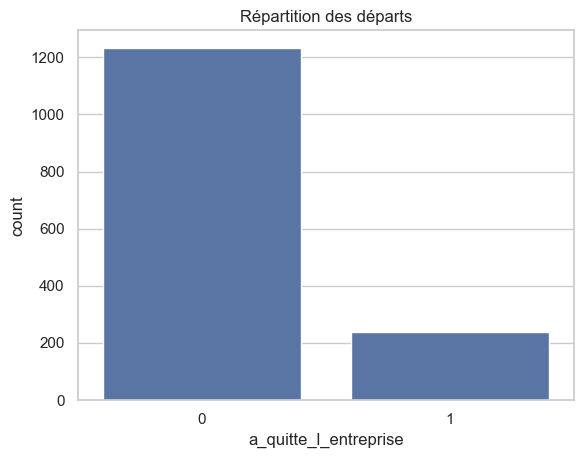

In [17]:
sns.countplot(data=df_central, x="a_quitte_l_entreprise")
plt.title("Répartition des départs")
plt.show()

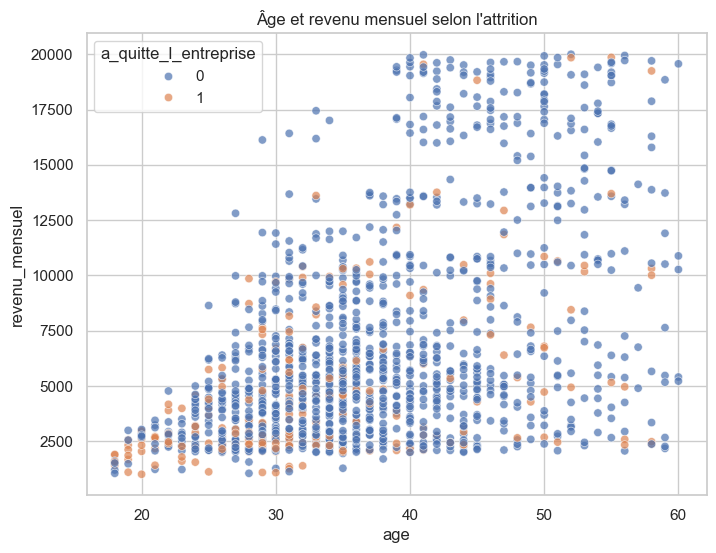

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_central,
    x="age",
    y="revenu_mensuel",
    hue="a_quitte_l_entreprise",
    alpha=0.7
)
plt.title("Âge et revenu mensuel selon l'attrition")
plt.show()

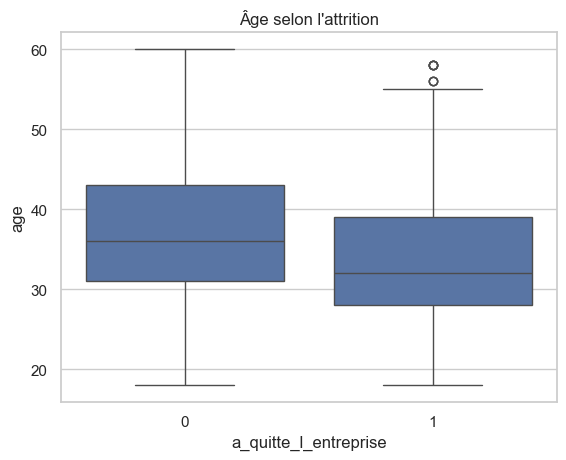

In [28]:
sns.boxplot(data=df_central, x="a_quitte_l_entreprise", y="age")
plt.title("Âge selon l'attrition")
plt.show()

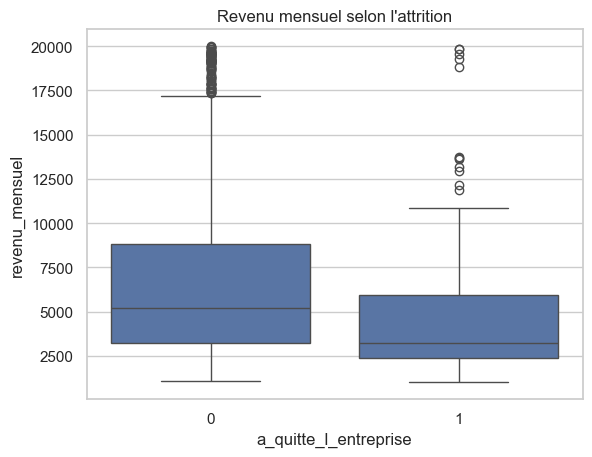

In [29]:
sns.boxplot(data=df_central, x="a_quitte_l_entreprise", y="revenu_mensuel")
plt.title("Revenu mensuel selon l'attrition")
plt.show()

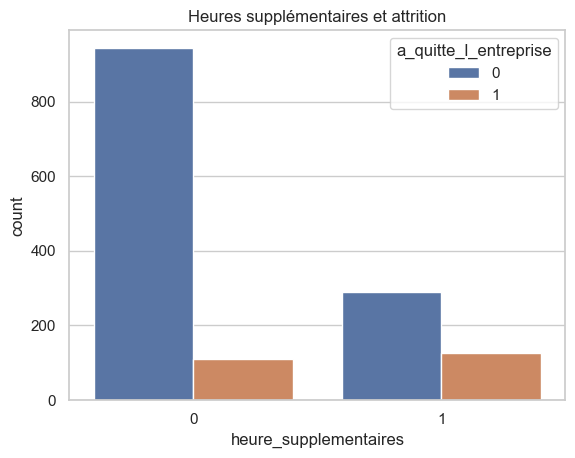

In [20]:
sns.countplot(data=df_central, x="heure_supplementaires", hue="a_quitte_l_entreprise")
plt.title("Heures supplémentaires et attrition")
plt.show()

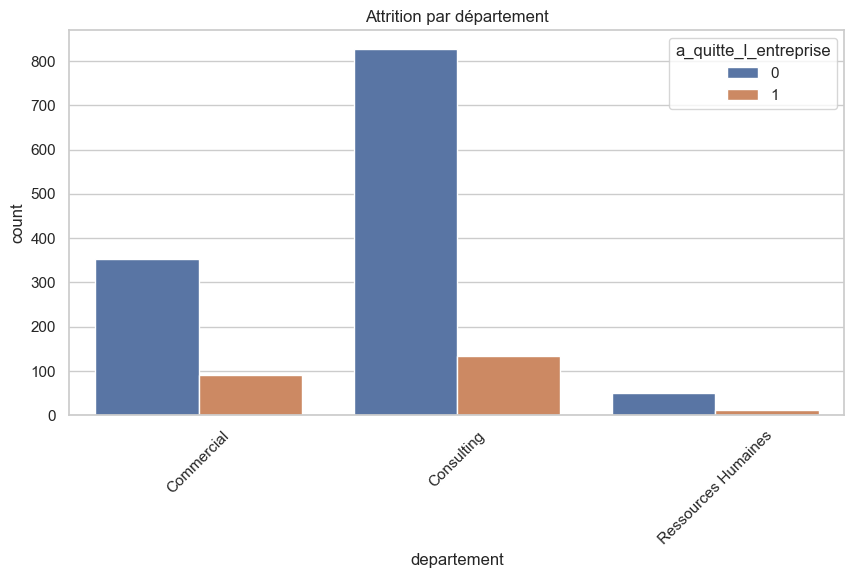

In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_central, x="departement", hue="a_quitte_l_entreprise")
plt.title("Attrition par département")
plt.xticks(rotation=45)
plt.show()

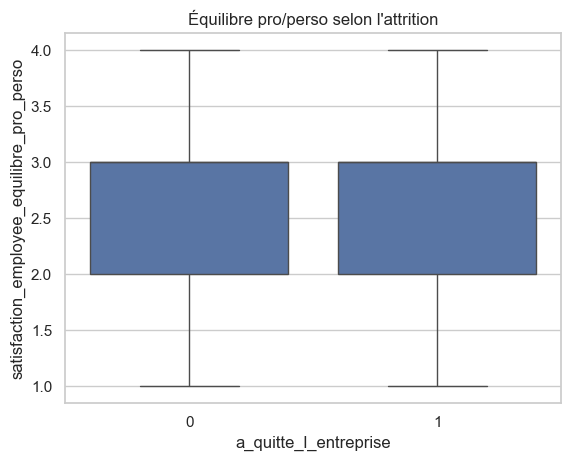

In [22]:
sns.boxplot(data=df_central, x="a_quitte_l_entreprise", y="satisfaction_employee_equilibre_pro_perso")
plt.title("Équilibre pro/perso selon l'attrition")
plt.show()

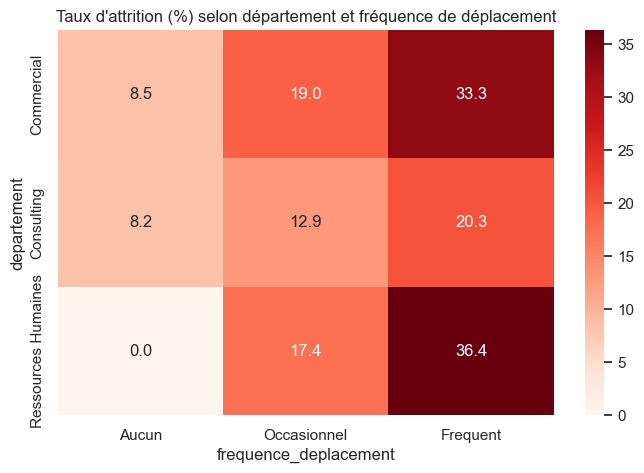

In [39]:
multi = pd.crosstab(
    [df_central["departement"], df_central["frequence_deplacement"]],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
).reset_index()

multi = multi.rename(columns={1: "taux_attrition"})
pivot_multi = multi.pivot(
    index="departement",
    columns="frequence_deplacement",
    values="taux_attrition"
)

pivot_multi = pivot_multi.reindex(columns=["Aucun", "Occasionnel", "Frequent"])

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_multi * 100, annot=True, fmt=".1f", cmap="Reds")
plt.title("Taux d'attrition (%) selon département et fréquence de déplacement")
plt.show()

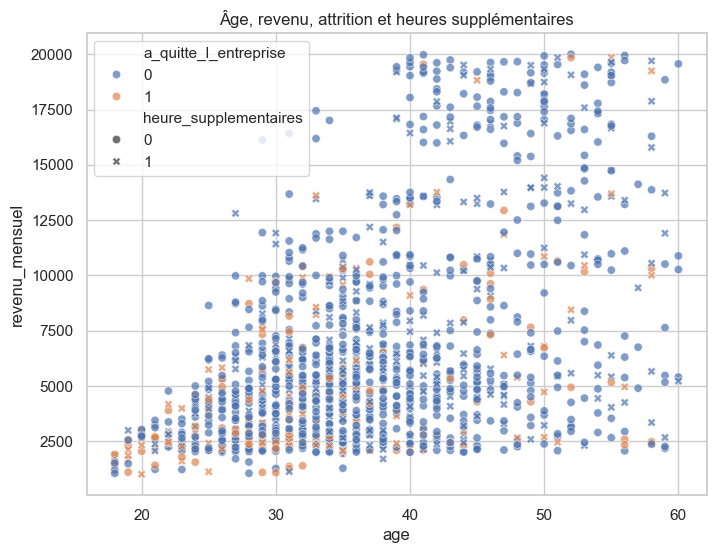

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_central,
    x="age",
    y="revenu_mensuel",
    hue="a_quitte_l_entreprise",
    style="heure_supplementaires",
    alpha=0.7
)
plt.title("Âge, revenu, attrition et heures supplémentaires")
plt.show()